In [1]:
import jax
import jax.numpy as jnp
from jax import grad, jit, vmap, jacfwd, jacrev
import numpy as np 
import plotly.express as px
import plotly.graph_objects as go

In [23]:
# Initialize MLP

# initialize the parameters for the MLP
def init_params(layers_sizes, key):
    params = []
    for n_in, n_out in zip(layer_sizes[:-1], layer_sizes[1:]):
        key, subkey = jax.random.split(key)
        scale = jnp.sqrt(2.0 / (n_in + n_out))
        W = jax.random.normal(subkey, (n_in, n_out)) * scale
        b = jnp.zeros(n_out)
        params.append((W,b))
    return params

# calculate the forward pass of the MLP f(x; \theta)
def mlp_forward(params, x):
    x = jnp.atleast_1d(x)
    for W, b in params[:-1]:
        x = jax.nn.relu(x @ W + b)
    W, b = params[-1]
    x = x @ W + b
    return x.squeeze()

In [27]:
# Compute Neural Tangent Kernel:
# The neural tangent kernel is defined as the inner product of the Jacobians (for the network ouput)
# with respect to each parameter, evaluated at the current parameter vector

# flatten all of the parameters into a single vector
def flatten_params(params):
    leaves = jax.tree_util.tree_leaves(params)
    return jnp.concatenate([p.ravel() for p in leaves])

# scalar output model needed for jacobian computation
def model_fn(params, x):
    return mlp_forward(params, x)

# compute the jacobian (derivative of f(x) with respect to theta ), then flatten
def jacobian_wrt_params(params, x):
    jac = jacrev(model_fn)(params, x)
    leaves = jax.tree_util.tree_leaves(jac)
    return jnp.concatenate([l.ravel() for l in leaves])

In [21]:
# compute the actual neural tangent kernel
def ntk(params, x1, x2):
    j1 = jacobian_wrt_params(params, x1)
    j2 = jacobian_wrt_params(params, x2)
    return jnp.dot(j1, j2)

# compute the full NTK matrix for a dataset of inputs
def compute_ntk_matrix(params, xs):
    ntk_single = jit(ntk)

    N = len(xs)
    K = np.zeros((N,N))
    for i in range(N):
        for j in range(i, N):
            val = float(ntk_single(params, xs[i], xs[j]))
            K[i, j] = val
            K[j, i] = val
    return K 

In [34]:
# initialize MLP parameters
layer_sizes = [1, 64, 64, 64, 1]
key = jax.random.PRNGKey(42)
params = init_params(layer_sizes, key)

In [17]:
n_params = sum(W.size + b.size for W, b in params)
n_params

8513

In [41]:
# in this case our dataset is just a grid of inputs in [-3, 3]
N = 100
xs = jnp.linspace(-2.0, 2.0, N)

# so we may visualize the kernel just by computing the kernel matrix
K = compute_ntk_matrix(params, xs)

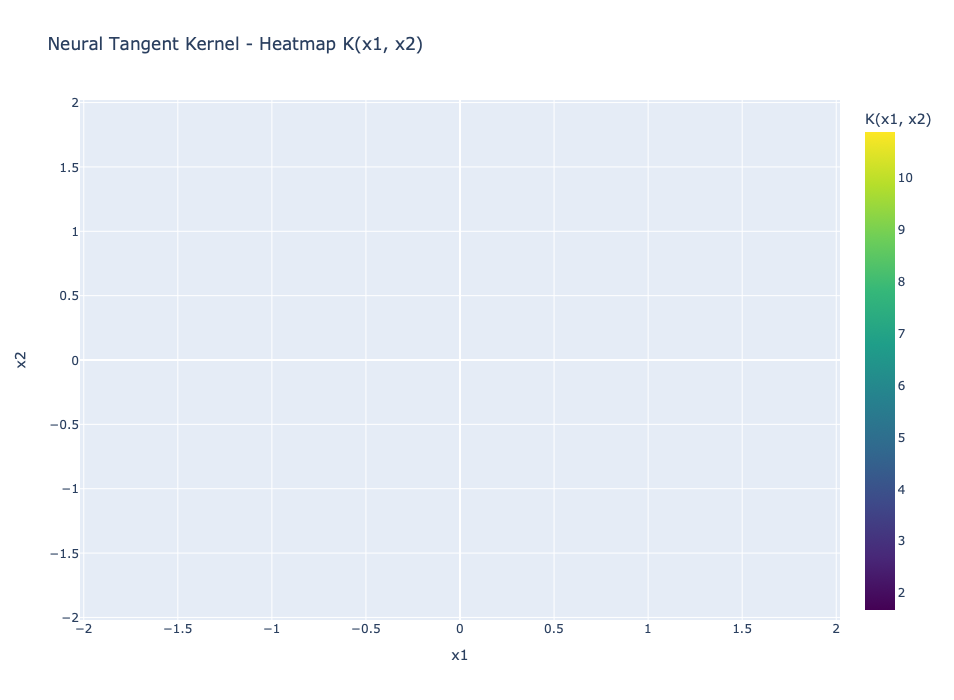

In [42]:
fig_heatmap = go.Figure(
    go.Heatmap(
        z = K, 
        x = np.round(xs, 2), 
        y = np.round(xs, 2),
        colorscale = "Viridis",
        colorbar = dict(title="K(x1, x2)")
    )
)
fig_heatmap.update_layout(
    title = "Neural Tangent Kernel - Heatmap K(x1, x2)",
    xaxis_title = "x1",
    yaxis_title = "x2",
    width = 700,
    height = 700
)
fig_heatmap.show()